# VQLS for the Linear Pendulum

In this notebook, we study the application of the Variational Quantum Linear Solver (VQLS) to the linear pendulum equation. The goal is to understand how a simple second-order ordinary differential equation can be rewritten as a first-order system, discretized using a time-stepping method, and solved step by step using VQLS.

The linear pendulum is a useful benchmark problem because its dynamics are well understood. This allows us to compare the VQLS-based solution with a classical numerical solution and study how the VQLS performance depends on numerical and physical parameters.

In particular, we study the effect of:

- the time-step size ($h$),
- the pendulum frequency ($\omega$),
- the ansatz depth,
- the condition number of the linear system,
- the VQLS residual and optimization cost.

## Linear Pendulum Equation

For small angular displacements, the pendulum equation reduces to the linear equation

$$
\ddot{x} = -\omega^2 x,
$$

where $x(t)$ is the displacement and $\omega$ is the natural frequency.

To apply a time-stepping method, we rewrite the second-order equation as a first-order system by defining

$$
y = \dot{x}.
$$

Then,

$$
\dot{x} = y,
$$

$$
\dot{y} = -\omega^2 x.
$$

This gives the first-order system

$$
\frac{d}{dt}
\begin{pmatrix}
x \\
y
\end{pmatrix}
=
\begin{pmatrix}
0 & 1 \\
-\omega^2 & 0
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}.
$$

## Euler Discretization and Matrix Form

Using the forward Euler method with time step ($h$),

\begin{align}
    x_{n+1} &= x_n + h y_n, \\
    y_{n+1} & = y_n - h \omega^2 x_n.
\end{align}
Writing them as a matrix equation in the form as 
\begin{align}
    \begin{pmatrix} 1 & 0 & 0 & 0\\ 0 & 1 & 0 & 0\\-1&-h&1&0\\h\omega^2 & -1 & 0 &1 \end{pmatrix} 
    \begin{pmatrix} x_n \\ y_n \\ x_{n+1} \\ y_{n+1} \end{pmatrix} & = \begin{pmatrix} x_n \\ y_n \\ 0 \\ 0 \end{pmatrix} \\
    A \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ X  \ \ \ \ & = \ \ \ \ \ \ b
\end{align}
The first two rows of the matrix fix the current state, while the last two rows impose the Euler update equations. After solving for ($X$), the components ($x_{n+1}$) and ($y_{n+1}$) are used to construct the right-hand side for the next time step.

## Imports and Basic Helper Functions

We first import the required numerical and quantum-computing libraries. The implementation uses Qiskit for quantum circuits and statevector simulation, SciPy for classical optimization, and NumPy/Pandas/Matplotlib for numerical analysis and plotting.

In [1]:
#Importing necessary packages and functions
from qiskit import QuantumCircuit,transpile
import numpy as np
from qiskit.quantum_info import SparsePauliOp, DensityMatrix, Statevector
from qiskit.circuit.library import TwoLocal,n_local
from scipy.optimize import minimize
from qiskit_aer.primitives import EstimatorV2
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator

estimator = EstimatorV2()


## Constructing the Linear System

The function below constructs the matrix \(A\) corresponding to the Euler-discretized linear pendulum system. For fixed \(h\) and $\omega$, the same matrix is used at every time step. The right-hand side vector \(b\), however, changes at each step because it depends on the current state.

The VQLS cost function uses normalized quantum states. Therefore, we define a normalization function for vectors. We also define a classical linear solver using `np.linalg.solve`, which provides a reference solution for each linear system.

In [2]:
#creating Matrix A
def create_matrix_linear(omega,h,n):
    mat = np.zeros((n,n))
    for i in range(n):
        mat[i,i] = 1
    mat[2,0] = -1
    mat[2,1] = - h
    mat[3,0] = h*omega*omega
    mat[3,1] = -1
    return mat

#creating b vector
def create_bvec_linear(xi,yi):
    b = np.array([xi,yi,0,0],dtype = float)
    return b

#Creating function to normalize a vector
def normalize(v):
    return v / np.linalg.norm(v)

#generating a classical solution (raw and normalized) 
def classical_solution_raw(A, b):
    x = np.linalg.solve(A, b)
    return x

def classical_solution(A, b):
    x = np.linalg.solve(A, b)
    return normalize(x)

#defining dagger of an opertor
def A_dagger(A_op):
    return A_op.adjoint()

In [3]:
#Generating pauli terms from an operator
def op_from_matrix(M):
    return SparsePauliOp.from_operator(M)

def n_of_qubits(n):
    return int(np.log2(n))

#Creating an identity pauli term, i.e II or III or ... 
def identity_op(n_qubits):
    return SparsePauliOp.from_list([("I"*n_qubits, 1.0)])

## VQLS Cost Hamiltonian

The VQLS algorithm approximates the solution of a linear system by preparing a parameterized quantum state \(|x(\theta)\rangle\). The parameters are optimized so that \(A|x(\theta)\rangle\) becomes proportional to the normalized right-hand side state \(|b\rangle\).

Here we use a projector-based cost function of the form

$$
C(\theta) =
\langle x(\theta)|
A^\dagger
\left(I - |b\rangle\langle b|\right)
A
|x(\theta)\rangle.
$$

This cost becomes small when $A|x(\theta)\rangle$ is aligned with $|b\rangle$. The operator corresponding to this expression is constructed as a Pauli operator so that its expectation value can be estimated using the quantum circuit.

In [4]:
#Creating cost Hamiltonian matrix
def cost_hamiltonian(A_op, b_state,n):
    n_qubits = n_of_qubits(n)
    I = identity_op(n_qubits)
    B_dm = DensityMatrix(b_state)           # |b><b|
    B_op = op_from_matrix(B_dm)
    A_dag = A_dagger(A_op)
    H = A_dag @ (I - B_op) @ A_op
    # hermitianize & real-coeff cleanup
    H = 0.5*(H + H.adjoint())
    H = SparsePauliOp(H.paulis, coeffs=np.real(H.coeffs))
    return H

## Ansatz Circuit

The variational ansatz prepares the trial solution state $|x(\theta)\rangle$. In this notebook, we use an $n$-local circuit built from ($R_y$) rotations and CNOT entangling gates with linear entanglement.

The ansatz depth is controlled by the parameter `reps`. Increasing `reps` can improve expressibility, but it also increases the number of variational parameters and the optimization cost.

In [5]:
#Creating ansatz (n-local circuit)
def make_ansatz(n_qubits,reps):
    return n_local(n_qubits, rotation_blocks="ry", entanglement_blocks="cx", entanglement="linear", reps=reps,insert_barriers = False)

#Pauli Count
def pauli_term_count(op: SparsePauliOp):
    return len(op.paulis)

#Generating statevector from parameters from the solution
def state_from_params(ansatz, params):
    qc = QuantumCircuit(ansatz.num_qubits)
    qc.compose(ansatz.assign_parameters(params), inplace=True)
    return Statevector.from_instruction(qc).data


## Multi-Step VQLS Solver

The function below implements the multi-step VQLS procedure for the linear pendulum.

At each time step:

1. Construct the normalized right-hand side state $|b\rangle$.
2. Build the VQLS cost Hamiltonian.
3. Optimize the ansatz parameters.
4. Extract the approximate quantum solution.
5. Rescale the normalized quantum state to obtain an unnormalized solution vector.
6. Update the state $(x_n,y_n)\rightarrow(x_{n+1},y_{n+1})$.
7. Store diagnostic quantities such as the cost, residual, optimizer iterations, and trajectory error.

The residual
$
\|Ax-b\|
$
measures how well the VQLS output solves the linear system at each step.

In [6]:
#Function to run VQLS
def run_vqls_linear(n,xi,yi,h,omega,nf,reps,cost_type="projector", optimizer="COBYLA",maxiter=500,seed = 0):
    np.random.seed(seed)

    #matrix and vector
    Amat = create_matrix_linear(omega,h,n)
    b_vec_q = create_bvec_linear(xi,yi)
    b_vec_cl = create_bvec_linear(xi,yi)
    A_op = op_from_matrix(Amat)
    n_q = n_of_qubits(n)
    I2 = identity_op(n_q)
    kappa = np.linalg.cond(Amat)

    #making ansatz
    ansatz = make_ansatz(n_q,reps)

    #Define the cost function
    def costfunc(params):
        if cost_type == "projector":
            job = estimator.run([(ansatz,Ham,params)])
            result = job.result()
            value  = result[0].data.evs
            return value

    #Creating a VQLS loop
    x_vqls = np.zeros(nf)
    x_vqls[0] = b_vec_q[0] 
    x_cl = np.zeros(nf)
    x_cl[0] = b_vec_cl[0]

    costs = []
    iters = []
    residuals = []
    
    for i in range(1,nf):
        B_vec = normalize(b_vec_q)

        #Cost Hamiltonian
        Ham = cost_hamiltonian(A_op, B_vec,n)
        
        #Optimization
        if i == 1:
            initial_params = np.random.uniform(0, 2*np.pi, ansatz.num_parameters)
        else:
            initial_params = optimal_params
    
        res = minimize(costfunc, initial_params, method=optimizer,options={'maxiter': maxiter,'tol': 1e-10})
    
        #finding optimal parameters
        optimal_params = res.x
        # Evaluate final state
        x_quant = state_from_params(ansatz, optimal_params)   
    
        #finding the alpha for AX = alpha b and find the unormalized quantum solution
        xhat = x_quant
        Axhat = Amat @ xhat
        c = np.vdot(b_vec_q, Axhat) / np.vdot(Axhat, Axhat)
        x_q = c * xhat
        
        #Creating a real quantum solution by removing img parts
        x_qm = np.zeros(n)
        for k in range(n):
            x_qm[k] = x_q[k].real

        costs.append(res.fun)
        iters.append(res.nfev)
        residuals.append(np.linalg.norm(Amat @ x_q - b_vec_q))

        #Finding classical solution, storing in x_fin_cl and updateing classical b vector
        x_cl_one = classical_solution_raw(Amat, b_vec_cl)
        b_vec_cl[0] = x_cl_one[2]
        b_vec_cl[1] = x_cl_one[3]
        x_cl[i] = x_cl_one[2]

        #update B vector and store the final solution in x_fin
        b_vec_q[0] = x_qm[2]
        b_vec_q[1] = x_qm[3]
        x_vqls[i] = x_qm[2]
    
    #Errors
    trajectory_error = np.abs(x_cl - x_vqls)
    final_error = np.abs(x_cl[-1] - x_vqls[-1])
    mean_error = np.mean(np.abs(x_cl - x_vqls))
    max_error = np.max(np.abs(x_cl - x_vqls))
    
    return {
        "n": n,
        "h": h,
        "omega": omega,
        "condition_number": kappa,
        "reps": reps,
        "cost_type": cost_type,
        "optimizer": optimizer,
        "costs": np.array(costs),
        "iters": np.array(iters),
        "residuals": np.array(residuals),
        "x_vqls": x_vqls,
        "x_cl": x_cl,
        "trajectory_err":trajectory_error,
        "fin_err": final_error,
        "mean_err":mean_error,
        "max_err":max_error
    }

## Sanity Check

We first run the solver for a small number of time steps to verify that the code executes correctly and that the VQLS solution agrees with the classical linear solve for a simple parameter choice.

In [7]:
run_vqls_linear(n=4,xi=1,yi=0,h=0.01,omega=1,nf=5,reps=2,cost_type="projector", optimizer="COBYLA",maxiter=500,seed = 0)

{'n': 4,
 'h': 0.01,
 'omega': 1,
 'condition_number': np.float64(2.618151069894847),
 'reps': 2,
 'cost_type': 'projector',
 'optimizer': 'COBYLA',
 'costs': array([1.66533454e-15, 5.55111512e-15, 2.22044605e-15, 2.55351296e-15]),
 'iters': array([199, 203, 236, 223]),
 'residuals': array([6.52540493e-08, 1.11307846e-07, 7.42151196e-08, 7.76421824e-08]),
 'x_vqls': array([1.        , 0.99999999, 0.99989999, 0.99969999, 0.99939999]),
 'x_cl': array([1.        , 1.        , 0.9999    , 0.9997    , 0.99940001]),
 'trajectory_err': array([0.00000000e+00, 1.24935137e-08, 1.43365824e-08, 1.07201862e-08,
        1.63084988e-08]),
 'fin_err': np.float64(1.6308498773653923e-08),
 'mean_err': np.float64(1.077175619812465e-08),
 'max_err': np.float64(1.6308498773653923e-08)}

## Parameter Scan

We now run the multi-step VQLS solver for different values of the time-step size \(h\), pendulum frequency $\omega$, and ansatz depth `reps`.

The goal is to study how these parameters affect:

- the condition number of the matrix \(A\),
- the VQLS residual,
- the trajectory error,
- the optimizer effort,
- and the runtime.

The results are saved after each run so that long simulations do not need to be repeated.

In [7]:
#For different values of h, omega, ansatz depth (reps) and cost function types
import time
import datetime
import pickle
import os

# file name
save_file = "results_linear_pd.pkl"

# Load existing results if file exists
if os.path.exists(save_file):
    with open(save_file, "rb") as f:
        results = pickle.load(f)
    print(f"Loaded {len(results)} existing results")
else:
    results = []

def already_done(results, h, omega, reps):
    for r in results:
        if r["h"] == h and r["omega"] == omega and r["reps"] == reps:
            return True
    return False

#parameter lists
h_list = [0.001, 0.01, 0.1]
omega_list = [0.5, 1, 3, 5]
reps_list = [1, 2, 3]

#h_list = [0.01]
#omega_list = [1]
#reps_list = [2]

total_cases = len(h_list) * len(omega_list) * len(reps_list)
print(f"Total number of parameter cases: {total_cases}")

time_all = 0

# parameter loops
for h in h_list:
    for omega in omega_list:
        for reps in reps_list:
            print(f"Running: h={h}, omega={omega}, reps={reps}")

            t0 = time.time()

            out = run_vqls_linear(
                n=4,xi=1,yi=0, h=h, omega=omega, nf=100, reps=reps, cost_type="projector", optimizer="COBYLA", maxiter=500,seed=1)

            t1 = time.time()

            # Add metadata
            out["runtime_sec"] = t1 - t0
            out["runtime_min"] = (t1 - t0) / 60
            out["timestamp"] = time.time()
            out["time_str"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            out["nf"] = 100

            results.append(out)

            print(f"Done in {out['runtime_sec']:.2f} sec")

            time_all = time_all + out["runtime_min"]

            # Save after each case
            with open(save_file, "wb") as f:
                pickle.dump(results, f)

print("All runs complete!")
print(f"Done in {time_all} min")

Total number of parameter cases: 36
Running: h=0.001, omega=0.5, reps=1
Done in 72.36 sec
Running: h=0.001, omega=0.5, reps=2
Done in 115.78 sec
Running: h=0.001, omega=0.5, reps=3
Done in 139.55 sec
Running: h=0.001, omega=1, reps=1
Done in 74.39 sec
Running: h=0.001, omega=1, reps=2
Done in 132.65 sec
Running: h=0.001, omega=1, reps=3
Done in 138.17 sec
Running: h=0.001, omega=3, reps=1
Done in 102.83 sec
Running: h=0.001, omega=3, reps=2
Done in 153.26 sec
Running: h=0.001, omega=3, reps=3
Done in 192.33 sec
Running: h=0.001, omega=5, reps=1
Done in 100.00 sec
Running: h=0.001, omega=5, reps=2
Done in 156.20 sec
Running: h=0.001, omega=5, reps=3
Done in 157.96 sec
Running: h=0.01, omega=0.5, reps=1
Done in 79.85 sec
Running: h=0.01, omega=0.5, reps=2
Done in 207.21 sec
Running: h=0.01, omega=0.5, reps=3
Done in 139.20 sec
Running: h=0.01, omega=1, reps=1
Done in 115.71 sec
Running: h=0.01, omega=1, reps=2
Done in 160.45 sec
Running: h=0.01, omega=1, reps=3
Done in 146.63 sec
Running

# Comparison Plots

## Collecting Results into a DataFrame

After the simulations are complete, we collect the output dictionaries into a Pandas DataFrame. This makes it easier to compare different parameter choices and generate summary plots.

For each run, we store the condition number, final cost, residuals, trajectory errors, optimizer iterations, and runtime.

In [36]:
# Load saved results
with open("results_linear_pd.pkl", "rb") as f:
    results = pickle.load(f)

In [37]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert to dataframe
rows = []

for r in results:
    rows.append({
        "h": r["h"],
        "omega": r["omega"],
        "reps": r["reps"],
        "nf": r.get("nf", len(r["x_vqls"])),
        "condition_number": float(r["condition_number"]),

        "final_cost": float(r["costs"][-1]),
        "mean_cost": float(np.mean(r["costs"])),
        "max_cost": float(np.max(r["costs"])),

        "final_residual": float(r["residuals"][-1]),
        "mean_residual": float(np.mean(r["residuals"])),
        "max_residual": float(np.max(r["residuals"])),

        "final_error": float(r["fin_err"]),
        "mean_error": float(r["mean_err"]),
        "max_error": float(r["max_err"]),

        "mean_iters": float(np.mean(r["iters"])),
        "max_iters": float(np.max(r["iters"])),
        "total_iters": float(np.sum(r["iters"])),

        "runtime_sec": float(r.get("runtime_sec", np.nan)),
        "runtime_min": float(r.get("runtime_min", np.nan)),
        "time_str": r.get("time_str", "")
    })

df = pd.DataFrame(rows)
df = df.sort_values(["h", "omega", "reps"])

print(df.head())

       h  omega  reps   nf  condition_number    final_cost     mean_cost  \
0  0.001    0.5     1  100          2.618913 -2.220446e-16  3.711958e-16   
1  0.001    0.5     2  100          2.618913  6.661338e-16  1.460111e-15   
2  0.001    0.5     3  100          2.618913 -1.110223e-16  1.078823e-15   
3  0.001    1.0     1  100          2.618035  2.220446e-16  2.343804e-16   
4  0.001    1.0     2  100          2.618035 -3.330669e-16  3.179275e-15   

       max_cost  final_residual  mean_residual  max_residual   final_error  \
0  3.885781e-15    1.231987e-08   3.334364e-08  9.016839e-08  3.587582e-07   
1  8.548717e-15    4.384796e-08   5.313387e-08  1.326691e-07  6.959166e-07   
2  6.994405e-15    2.766951e-08   4.848815e-08  1.202588e-07  2.255395e-07   
3  4.551914e-15    3.866092e-08   3.432451e-08  1.002427e-07  1.240129e-08   
4  1.754152e-14    1.757455e-08   7.682569e-08  1.894042e-07  8.839861e-07   

     mean_error     max_error  mean_iters  max_iters  total_iters  \
0  1.

## VQLS Trajectory Compared with Classical Trajectory



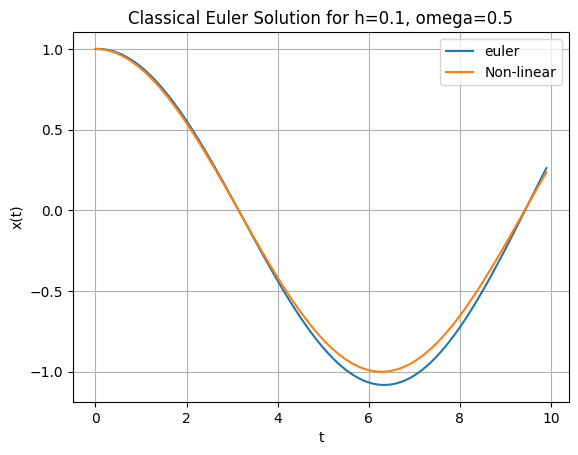

In [38]:
#Classical Euler solution 
import numpy as np

h_1 = 0.1
omega_1 = 0.5
nf_1 = 100
t_1 = np.arange(nf_1)*h_1
x_exact_1 = np.cos(omega_1*t_1)

# explicit Euler for comparison
x_e = np.zeros(nf_1); y_e = np.zeros(nf_1)
x_e[0]=1.0; y_e[0]=0.0
for i in range(nf_1-1):
    x_e[i+1] = x_e[i] + h_1*y_e[i]
    y_e[i+1] = y_e[i] - h_1*(omega_1**2)*x_e[i]

#Classical Euler Solution Plot

plt.plot(t_1,x_e,label='euler')
plt.plot(t_1,x_exact_1,label = 'Non-linear')

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title(f"Classical Euler Solution for h={h_1}, omega={omega_1}")
plt.legend()
plt.grid(True)
plt.show()


We first compare the VQLS-based time evolution with the classical Euler trajectory for a selected parameter set. This provides a direct visual check of whether the VQLS solution reproduces the expected pendulum motion.

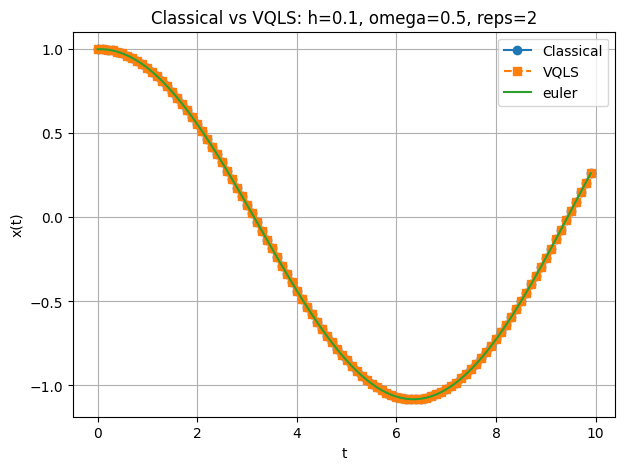

In [41]:
#Consider the same h and omega values as before for a comparison
h_target = 0.1
omega_target = 0.5
reps_target = 2

for r in results:
    if r["h"] == h_target and r["omega"] == omega_target and r["reps"] == reps_target:
        case = r
        break

nf = len(case["x_vqls"])
t = np.arange(nf) * h_target

plt.figure(figsize=(7,5))
plt.plot(t, case["x_cl"], marker="o", label="Classical") #obtained by inversing Ax=b step by step
plt.plot(t, case["x_vqls"], marker="s", linestyle="--", label="VQLS") #obtained by solving Ax=b step by step using VQLS
plt.plot(t,x_e,label='euler') #Obtained by classically generating solution

    

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title(f"Classical vs VQLS: h={h_target}, omega={omega_target}, reps={reps_target}")
plt.legend()
plt.grid(True)
plt.show()


For this parameter choice, the VQLS trajectory closely follows the classical Euler trajectory. Since both methods use the same discretized time-stepping scheme, the difference between the two curves mainly measures the solver error introduced by VQLS, rather than the discretization error of Euler's method.

## Trajectory Error versus Condition Number

The condition number $\kappa(A)$ measures how sensitive the solution of the linear system is to perturbations in the input data or numerical errors. In general, larger condition numbers indicate that the linear system is harder to solve accurately.

Here we compare the maximum trajectory error with the condition number for different ansatz depths.

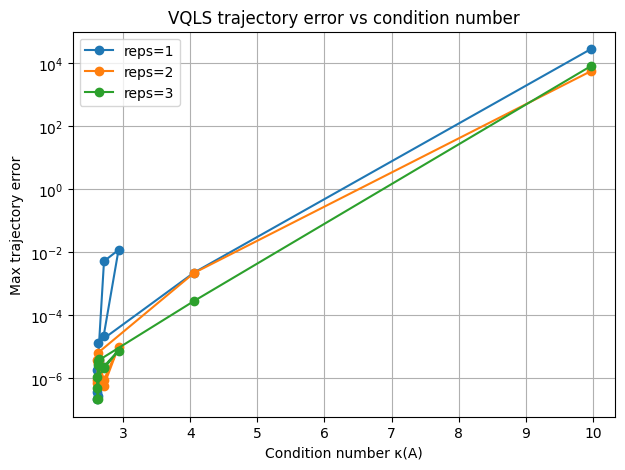

In [10]:
plt.figure(figsize=(7,5))

for reps in sorted(df["reps"].unique()):
    sub = df[df["reps"] == reps]
    plt.plot(
        sub["condition_number"],
        sub["max_error"], marker ="o",
        label=f"reps={reps}"
    )

plt.yscale("log")
plt.xlabel("Condition number κ(A)")
plt.ylabel("Max trajectory error")
plt.title("VQLS trajectory error vs condition number")
plt.legend()
plt.grid(True)
plt.show()

The results show that the trajectory error generally increases as the condition number grows. This indicates that the conditioning of the discretized matrix plays an important role in determining the accuracy of the VQLS-based time evolution.

The dependence on ansatz depth is not strictly monotonic. Increasing the ansatz depth can improve expressibility, but it also makes the optimization problem more difficult. Therefore, a deeper ansatz does not automatically guarantee better accuracy.

## Residual Error versus Condition Number

The residual $\|Ax-b\| $ measures how accurately the VQLS output solves the linear system at each time step. Unlike the trajectory error, which measures accumulated deviation in the time evolution, the residual is a direct diagnostic of the linear solver performance.

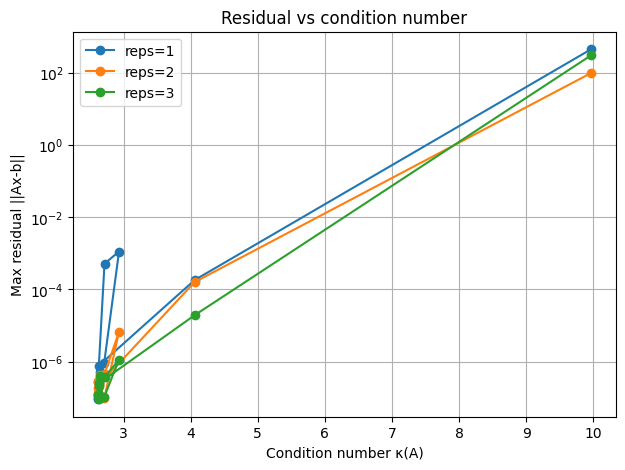

In [11]:
plt.figure(figsize=(7,5))

for reps in sorted(df["reps"].unique()):
    sub = df[df["reps"] == reps]
    plt.plot(
        sub["condition_number"],
        sub["max_residual"],marker ="o",
        label=f"reps={reps}"
    )

plt.yscale("log")
plt.xlabel("Condition number κ(A)")
plt.ylabel("Max residual ||Ax-b||")
plt.title("Residual vs condition number")
plt.legend()
plt.grid(True)
plt.show()

The residual increases with the condition number, showing that poorly conditioned systems are more difficult for VQLS to solve accurately. This trend is consistent with the behavior observed in the trajectory error.

## Optimization effort vs condition number

We also track the total number of optimizer function evaluations. This gives a practical measure of the computational effort required by the variational algorithm.

For multi-step VQLS, the total optimizer effort can become large because a new optimization is performed at each time step.

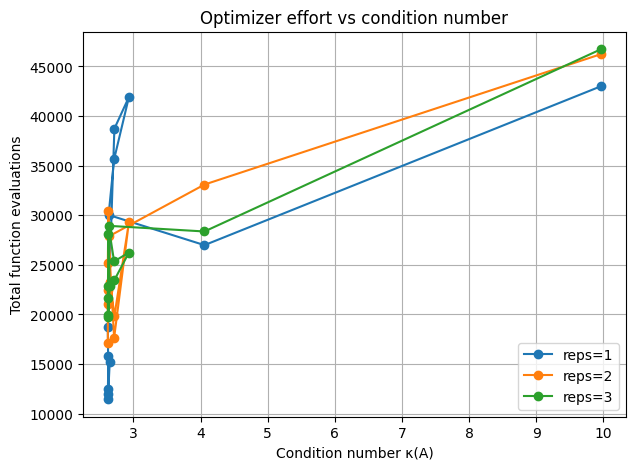

In [12]:
plt.figure(figsize=(7,5))

for reps in sorted(df["reps"].unique()):
    sub = df[df["reps"] == reps]
    plt.plot(
        sub["condition_number"],
        sub["total_iters"],marker="o",
        label=f"reps={reps}"
    )

plt.xlabel("Condition number κ(A)")
plt.ylabel("Total function evaluations")
plt.title("Optimizer effort vs condition number")
plt.legend()
plt.grid(True)
plt.show()

The optimizer effort generally increases for more difficult parameter regimes, although the trend is not perfectly smooth. This reflects the stochastic and nonlinear nature of variational optimization. The optimization effort also depends on the ansatz depth and on the initial parameters used at each time step.

In this implementation, the optimal parameters from the previous time step are used as the initial parameters for the next time step. This warm-start strategy can reduce the optimization cost because consecutive time steps are close to each other.

In [23]:
df.groupby("reps")[["max_error", "max_residual", "total_iters","condition_number"]].max()

,max_error,max_residual,total_iters,condition_number
reps,,,,
1,507.435544,451.864131,43008.0,9.965951
2,112.464210,99.007515,46244.0,9.965951
3,307.462690,306.957049,46740.0,9.965951


## Runtime versus Ansatz Depth

Increasing the ansatz depth increases the number of variational parameters and the circuit complexity. Therefore, one generally expects the runtime to increase with `reps`.

However, the actual runtime also depends on optimizer convergence, parameter initialization, and the difficulty of each linear system.

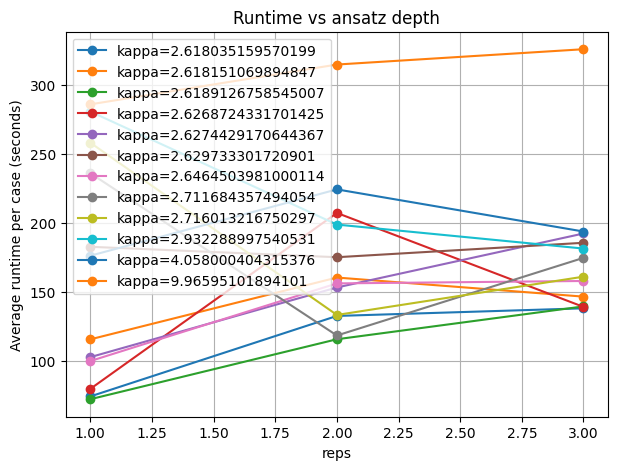

In [44]:
plt.figure(figsize=(7,5))

for con in sorted(df["condition_number"].unique()):
    sub = df[df["condition_number"] == con]
    grouped = sub.groupby("reps")["runtime_sec"].mean()

    plt.plot(grouped.index, grouped.values, marker="o", label=f"kappa={con}")

plt.xlabel("reps")
plt.ylabel("Average runtime per case (seconds)")
plt.title("Runtime vs ansatz depth")
plt.legend()
plt.grid(True)
plt.show()

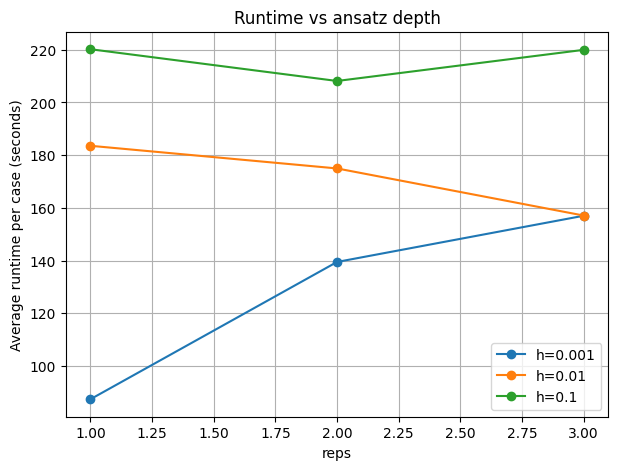

In [13]:
plt.figure(figsize=(7,5))

for h in sorted(df["h"].unique()):
    sub = df[df["h"] == h]
    grouped = sub.groupby("reps")["runtime_sec"].mean()

    plt.plot(grouped.index, grouped.values, marker="o", label=f"h={h}")

plt.xlabel("reps")
plt.ylabel("Average runtime per case (seconds)")
plt.title("Runtime vs ansatz depth")
plt.legend()
plt.grid(True)
plt.show()

The runtime does not increase perfectly monotonically with ansatz depth because the optimizer may converge in different numbers of function evaluations for different parameter choices. Nevertheless, deeper ansatz circuits generally introduce more computational overhead.

## Effect of Ansatz Depth (Error vs reps)

We now study how the ansatz depth affects the VQLS trajectory error. A larger value of `reps` gives a more expressive variational circuit, but it also increases the number of parameters and may make the optimization landscape more difficult.

Therefore, the relationship between ansatz depth and accuracy is not necessarily monotonic.

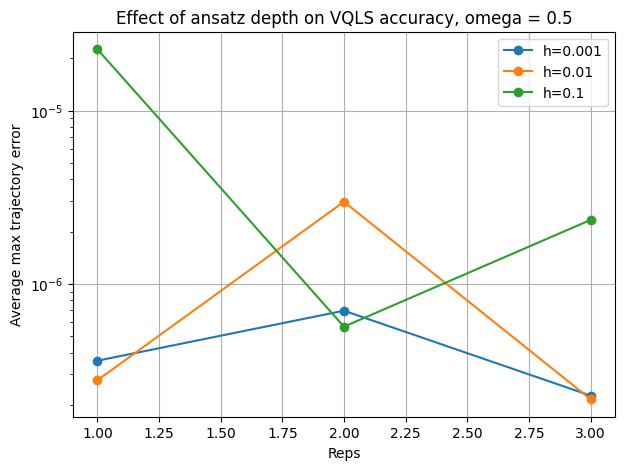

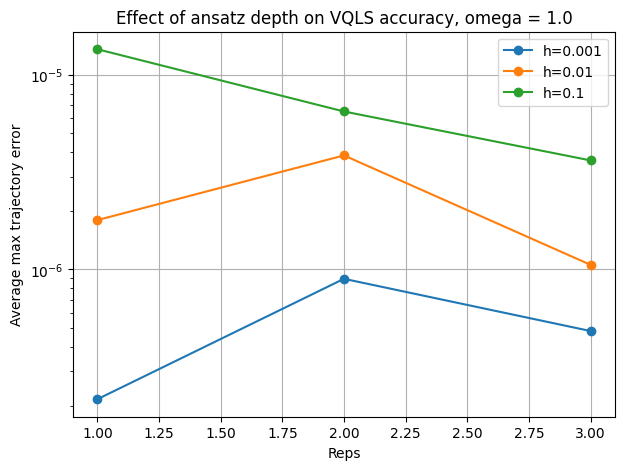

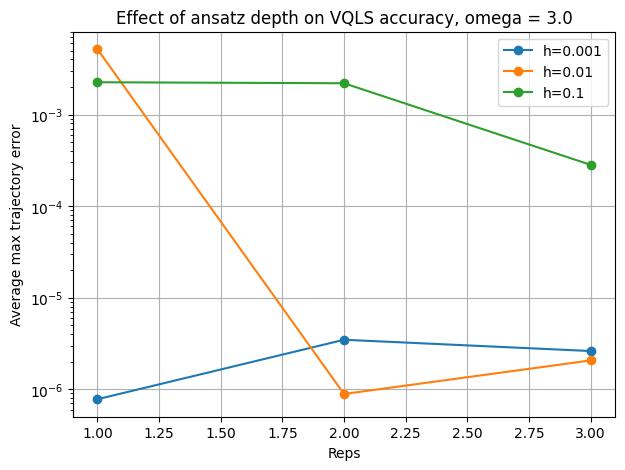

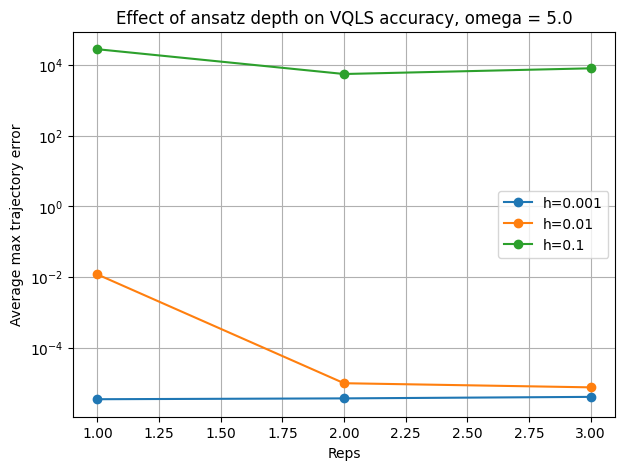

In [19]:
for omega in sorted(df["omega"].unique()):
    plt.figure(figsize=(7,5))
    
    for h in sorted(df["h"].unique()):
        sub = df[(df["h"] == h) & (df["omega"] == omega)]
        grouped = sub.groupby("reps")["max_error"].mean()
    
        plt.plot(
            grouped.index,
            grouped.values,
            marker="o",
            label = f"h={h}"
        )
    
    plt.yscale("log")
    plt.xlabel("Reps")
    plt.ylabel("Average max trajectory error")
    plt.title(f"Effect of ansatz depth on VQLS accuracy, omega = {omega}")
    plt.legend()
    plt.grid(True)
    plt.show()

The results show that increasing the ansatz depth can improve accuracy in some cases, but not uniformly across all parameter choices. This suggests that ansatz expressibility and optimizer performance must be considered together.

## Heat Map of Trajectory Error(for fixed reps)

The heatmaps summarize how the maximum trajectory error depends on the time-step size \(h\) and frequency $\omega$ for each ansatz depth.

Each cell shows the logarithm of the maximum trajectory error, while the text inside the cell gives the condition number of the corresponding matrix. This allows us to compare the accuracy and conditioning across the full parameter grid.

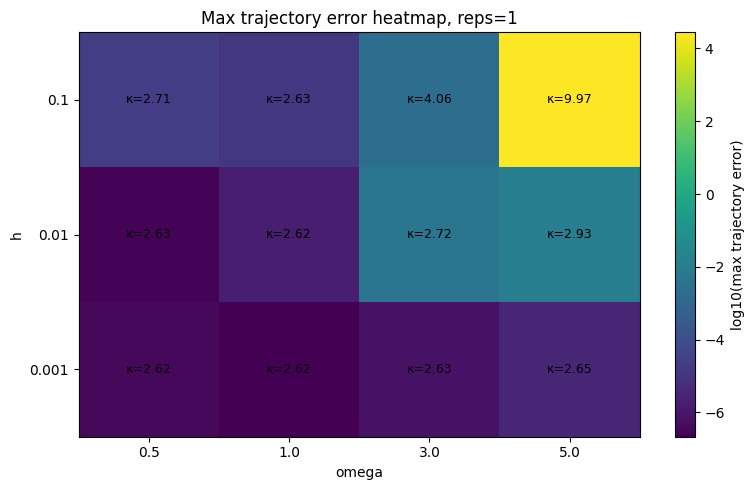

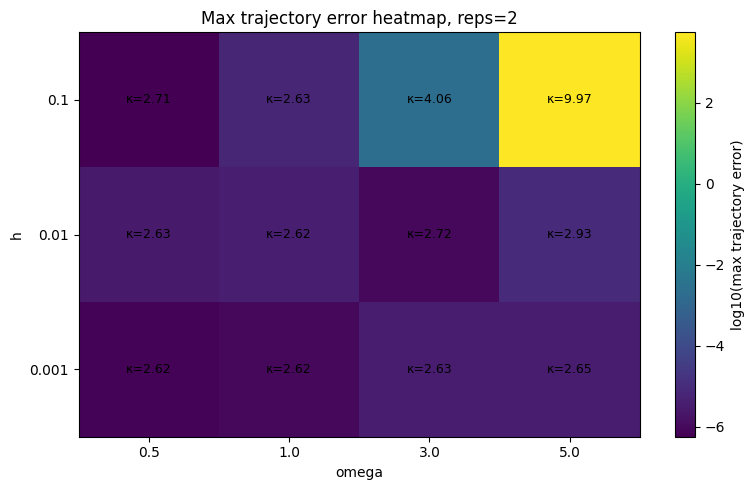

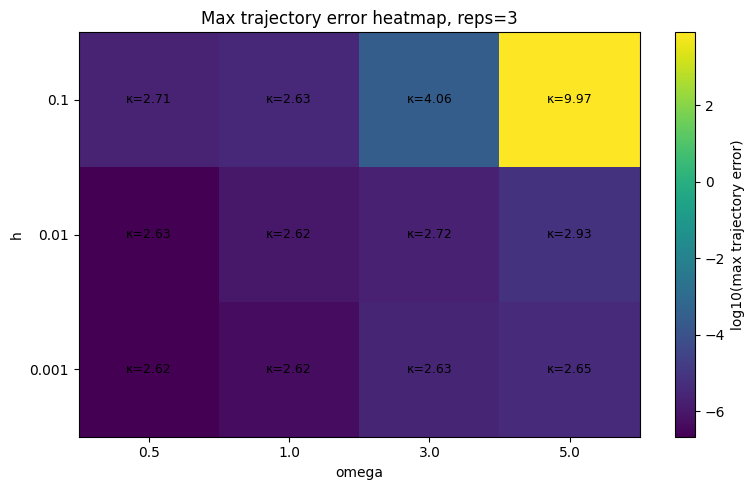

In [20]:
for reps_fixed in sorted(df["reps"].unique()):
    sub = df[df["reps"] == reps_fixed]

    err_pivot = sub.pivot(index="h", columns="omega", values="max_error")
    kappa_pivot = sub.pivot(index="h", columns="omega", values="condition_number")

    plt.figure(figsize=(8,5))

    im = plt.imshow(
        np.log10(err_pivot.values),
        aspect="auto",
        origin="lower"
    )

    plt.colorbar(im, label="log10(max trajectory error)")
    plt.xticks(range(len(err_pivot.columns)), err_pivot.columns)
    plt.yticks(range(len(err_pivot.index)), err_pivot.index)

    plt.xlabel("omega")
    plt.ylabel("h")
    plt.title(f"Max trajectory error heatmap, reps={reps_fixed}")

    for i in range(len(err_pivot.index)):
        for j in range(len(err_pivot.columns)):
            kappa_val = kappa_pivot.values[i, j]
            plt.text(j, i, f"κ={kappa_val:.2f}", ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

The heatmaps show that large values of \(h\) and $\omega$ lead to larger trajectory errors. This is consistent with the increase in the condition number of the discretized matrix. The most difficult regimes occur when the combination of time-step size and frequency makes the linear system poorly conditioned.

## Cost and residual error over time 

Finally, we examine how the VQLS cost and residual change during the time evolution for a selected parameter set. This helps determine whether the solver remains stable over many time steps or whether the error grows as the trajectory evolves.

In [28]:
def plot_diagnostics_case(results, h_target, omega_target, reps_target):
    case = None

    for r in results:
        if r["h"] == h_target and r["omega"] == omega_target and r["reps"] == reps_target:
            case = r
            break

    if case is None:
        print("Case not found.")
        return

    steps = np.arange(1, len(case["costs"]) + 1)

    # Convert to arrays
    costs = np.array(case["costs"], dtype=float)
    residuals = np.array(case["residuals"], dtype=float)

    # Avoid problems with log scale due to zero or tiny negative roundoff values
    eps = 1e-16
    costs_plot = np.maximum(np.abs(costs), eps)
    residuals_plot = np.maximum(np.abs(residuals), eps)

    plt.figure(figsize=(7,5))
    plt.plot(steps, costs_plot, marker="o")
    plt.yscale("log")
    plt.xlabel("Time step")
    plt.ylabel("Cost")
    plt.title(f"VQLS cost over time: h={h_target}, omega={omega_target}, reps={reps_target}")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(steps, residuals_plot, marker="o")
    plt.yscale("log")
    plt.xlabel("Time step")
    plt.ylabel("Residual ||Ax-b||")
    plt.title(f"Residual over time: h={h_target}, omega={omega_target}, reps={reps_target}")
    plt.grid(True)
    plt.show()



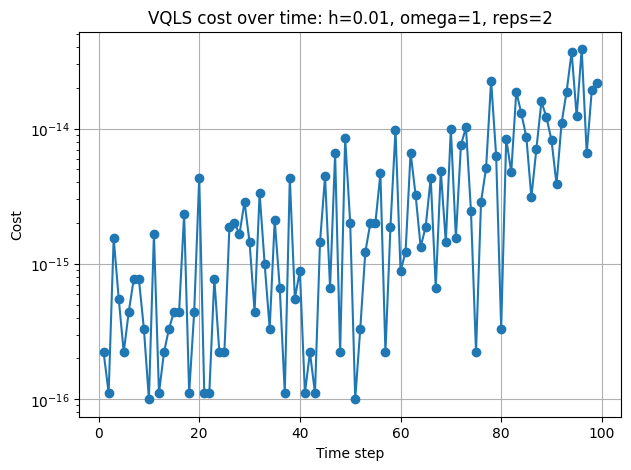

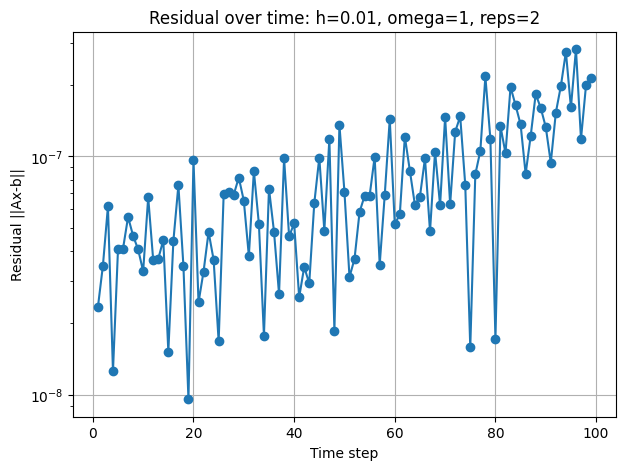

In [35]:
plot_diagnostics_case(results, h_target=0.01, omega_target=1, reps_target=2)

The cost and residual provide step-by-step diagnostics of the VQLS solver. If these quantities remain small, the VQLS optimization is successfully solving each local linear system. If they grow over time, this may indicate accumulated errors, poor conditioning, or optimization failure at later time steps.

## Summary

In this notebook, we studied the linear pendulum equation using a multi-step VQLS method.

The main steps were:

1. Rewrite the second-order pendulum equation as a first-order system.
2. Discretize the first-order system using the forward Euler method.
3. Construct a linear system $AX=b$ at each time step.
4. Solve each linear system using VQLS.
5. Compare the VQLS trajectory with a classical Euler reference solution.
6. Study the dependence on time-step size, pendulum frequency, condition number, and ansatz depth.

The results show that the VQLS trajectory can reproduce the classical Euler trajectory for well-conditioned parameter regimes. However, the accuracy degrades as the condition number increases. The ansatz depth also affects performance, but the improvement is not always monotonic because deeper circuits introduce more optimization complexity.

This linear pendulum example provides a useful benchmark for understanding the strengths and limitations of multi-step VQLS before moving to nonlinear systems.